# RFM CUSTOMER SEGMENTATION
BankTrust's Aims from this project:
- Customer Churn (Reduction of number of cutomers that churn)
- Personalisation (Improve on personalising each customer's experience with the bank)
- Marketing Efficiency (Aim to increase the marketing efficiency)

How to achieve this:
- Using RFM analysis, a data-driven technique used to segment customers based on their past behaviours.

Tools:

&#x1F4BB; Terminal, Git, VS Code, Jupyter Notebook

&#x1F40D; Python

&#x1F4DA; Libraries: pandas, numpy, matplotlib, seaborn, scikit-learn, streamlit

### Library Installation and Importation

In [1]:
!pip install pandas numpy seaborn matplotlib lifetimes scikit-learn -q


[notice] A new release of pip is available: 24.0 -> 25.1
[notice] To update, run: pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime

#setting display settings for the plots.
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

### DATA LOADING

In [4]:
df = pd.read_csv('dataset/banktrust_data.csv') #reading in the data.

df.info() #displaying information about the dataset.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1041614 entries, 0 to 1041613
Data columns (total 9 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   TransactionID            1041614 non-null  object 
 1   CustomerID               1041614 non-null  object 
 2   CustomerDOB              1041614 non-null  object 
 3   CustGender               1041614 non-null  object 
 4   CustLocation             1041614 non-null  object 
 5   CustAccountBalance       1041614 non-null  float64
 6   TransactionDate          1041614 non-null  object 
 7   TransactionTime          1041614 non-null  int64  
 8   TransactionAmount (INR)  1041614 non-null  float64
dtypes: float64(2), int64(1), object(6)
memory usage: 71.5+ MB


In [5]:
df.head() #displaying the first five rows of data.

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR)
0,T1,C5841053,10/1/94,F,JAMSHEDPUR,17819.05,2/8/16,143207,25.0
1,T2,C2142763,4/4/57,M,JHAJJAR,2270.69,2/8/16,141858,27999.0
2,T3,C4417068,26/11/96,F,MUMBAI,17874.44,2/8/16,142712,459.0
3,T4,C5342380,14/9/73,F,MUMBAI,866503.21,2/8/16,142714,2060.0
4,T5,C9031234,24/3/88,F,NAVI MUMBAI,6714.43,2/8/16,181156,1762.5


In [6]:
df.describe()

,CustAccountBalance,TransactionTime,TransactionAmount (INR)
count,1.041614e+06,1.041614e+06,1.041614e+06
mean,1.149986e+05,1.571221e+05,1.566096e+03
std,8.467609e+05,5.126352e+04,6.561464e+03
min,0.000000e+00,0.000000e+00,0.000000e+00
25%,4.728140e+03,1.240410e+05,1.600000e+02
50%,1.676852e+04,1.642470e+05,4.575000e+02
75%,5.742885e+04,2.000220e+05,1.200000e+03
max,1.150355e+08,2.359590e+05,1.560035e+06


### DATA CLEANING.

In [7]:
#checking for null values in the dataset.
df.isna().sum()

TransactionID              0
CustomerID                 0
CustomerDOB                0
CustGender                 0
CustLocation               0
CustAccountBalance         0
TransactionDate            0
TransactionTime            0
TransactionAmount (INR)    0
dtype: int64

_No null values._

In [8]:
#converting dates and times.
df['CustomerDOB'] = pd.to_datetime(df['CustomerDOB'], dayfirst=True) #dayfirst=True ensures that dates are not mistaken for American format.
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'], dayfirst=True, format='%d/%m/%y')

df.head() #viewing the data

/var/folders/_j/lsqnd2951cx6qmb_xfz2635m0000gn/T/ipykernel_25715/1691650888.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['CustomerDOB'] = pd.to_datetime(df['CustomerDOB'], dayfirst=True) #dayfirst=True ensures that dates are not mistaken for American format.


,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR)
0,T1,C5841053,1994-01-10,F,JAMSHEDPUR,17819.05,2016-08-02,143207,25.0
1,T2,C2142763,2057-04-04,M,JHAJJAR,2270.69,2016-08-02,141858,27999.0
2,T3,C4417068,1996-11-26,F,MUMBAI,17874.44,2016-08-02,142712,459.0
3,T4,C5342380,2073-09-14,F,MUMBAI,866503.21,2016-08-02,142714,2060.0
4,T5,C9031234,1988-03-24,F,NAVI MUMBAI,6714.43,2016-08-02,181156,1762.5


In [9]:
df['TransactionDate'].unique()

<DatetimeArray>
['2016-08-02 00:00:00', '2016-08-01 00:00:00', '2016-08-03 00:00:00',
 '2016-08-05 00:00:00', '2016-08-04 00:00:00', '2016-08-06 00:00:00',
 '2016-08-09 00:00:00', '2016-08-08 00:00:00', '2016-08-12 00:00:00',
 '2016-08-07 00:00:00', '2016-10-21 00:00:00', '2016-10-16 00:00:00',
 '2016-08-10 00:00:00', '2016-08-14 00:00:00', '2016-08-17 00:00:00',
 '2016-08-21 00:00:00', '2016-08-19 00:00:00', '2016-08-24 00:00:00',
 '2016-08-22 00:00:00', '2016-08-29 00:00:00', '2016-08-31 00:00:00',
 '2016-09-22 00:00:00', '2016-09-23 00:00:00', '2016-08-13 00:00:00',
 '2016-08-25 00:00:00', '2016-08-28 00:00:00', '2016-08-15 00:00:00',
 '2016-08-27 00:00:00', '2016-08-20 00:00:00', '2016-08-23 00:00:00',
 '2016-08-30 00:00:00', '2016-08-11 00:00:00', '2016-08-16 00:00:00',
 '2016-08-26 00:00:00', '2016-09-27 00:00:00', '2016-08-18 00:00:00',
 '2016-09-25 00:00:00', '2016-09-26 00:00:00', '2016-09-30 00:00:00',
 '2016-09-03 00:00:00', '2016-09-02 00:00:00', '2016-09-01 00:00:00',
 '20

#### CUSTOMER AGE
Calulcating the customer's age at the time of the transaction. Subtracting their date of birth from the transaction date.

In [10]:
def calculate_age(df):
    df['Age'] = (df['TransactionDate'] - df['CustomerDOB']).dt.days // 365
    return df

calculate_age(df) #calling the function
df.head(5)

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR),Age
0,T1,C5841053,1994-01-10,F,JAMSHEDPUR,17819.05,2016-08-02,143207,25.0,22
1,T2,C2142763,2057-04-04,M,JHAJJAR,2270.69,2016-08-02,141858,27999.0,-41
2,T3,C4417068,1996-11-26,F,MUMBAI,17874.44,2016-08-02,142712,459.0,19
3,T4,C5342380,2073-09-14,F,MUMBAI,866503.21,2016-08-02,142714,2060.0,-58
4,T5,C9031234,1988-03-24,F,NAVI MUMBAI,6714.43,2016-08-02,181156,1762.5,28


##### &#x1F4A5;	Issue with date of birth column has been observed, as some ages are negative. Viewing these specific ages.

In [11]:
#viewing the rows with negative ages.
print(df[df['Age'] <= 0]['CustomerDOB'])

print(f"The number of rows with negative ages is {len(df[df['Age'] <= 0]['CustomerDOB'])}")

1         2057-04-04
3         2073-09-14
5         2072-10-08
15        2068-07-10
29        2067-01-21
             ...    
1041553   2070-09-20
1041557   2048-07-15
1041583   2033-10-05
1041591   2071-10-05
1041599   2071-08-21
Name: CustomerDOB, Length: 104840, dtype: datetime64[ns]
The number of rows with negative ages is 104840


In [38]:
negative_ages = df[df['Age'] <= 0] #viewing these rows, to see if there's anything special we can notice

negative_ages

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR),Age
1,T2,C2142763,2057-04-04,M,JHAJJAR,2270.69,2016-08-02,141858,27999.00,-41
3,T4,C5342380,2073-09-14,F,MUMBAI,866503.21,2016-08-02,142714,2060.00,-58
5,T6,C1536588,2072-10-08,F,ITANAGAR,53609.20,2016-08-02,173940,676.00,-57
15,T16,C8334633,2068-07-10,F,NEW DELHI,1283.12,2016-08-01,125725,250.00,-52
29,T31,C7648712,2067-01-21,F,NEW DELHI,298461.05,2016-08-03,160642,500.00,-51
...,...,...,...,...,...,...,...,...,...,...
1041553,T1048507,C3333984,2070-09-20,M,NAVI MUMBAI,41.82,2016-09-18,182310,878.18,-55
1041557,T1048511,C3429427,2048-07-15,M,HOWRAH,416244.74,2016-09-18,184959,1695.00,-32
1041583,T1048537,C2939947,2033-10-05,M,NEW DELHI,92173.35,2016-09-18,184556,1319.04,-18
1041591,T1048545,C3712582,2071-10-05,M,MUMBAI,25414.52,2016-09-18,182015,400.00,-56


&#x1F441; No pattern can be noticed in the other columns of the rows. Also, looking at the figures for the DOB years, it looks like "20" should be "19", but this is a big assumption to make, so a smarter way to input the ages may need to be thought of. Attempting to fix this, rather than drop all the rows. To decide, let's visualize the ages and do further anaylis of the dataset.

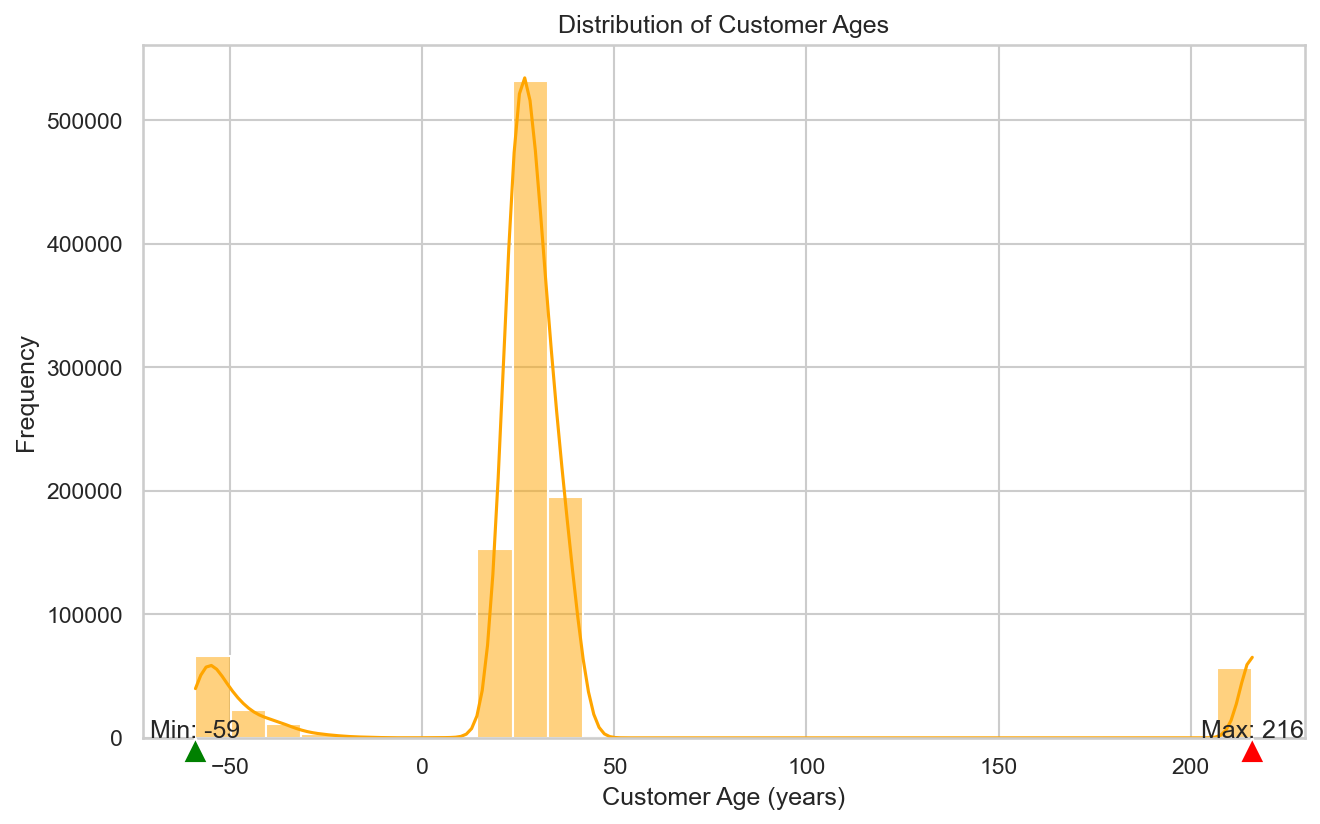

In [12]:
plt.figure(dpi=150) #so the plot is sharp/clear.

#to find min and max ages
min_age = df['Age'].min()
max_age = df['Age'].max()

#plotting the histogram with KDE
sns.histplot(df['Age'], bins=30, kde=True, color='orange')
plt.title('Distribution of Customer Ages')
plt.xlabel('Customer Age (years)')
plt.ylabel('Frequency')

#annotating min and max on x-axis
plt.annotate(f'Min: {min_age}', xy=(min_age, 0), xytext=(min_age, 5),
             arrowprops=dict(facecolor='green', shrink=0.05),
             ha='center')

plt.annotate(f'Max: {max_age}', xy=(max_age, 0), xytext=(max_age, 5),
             arrowprops=dict(facecolor='red', shrink=0.05),
             ha='center')

plt.show()

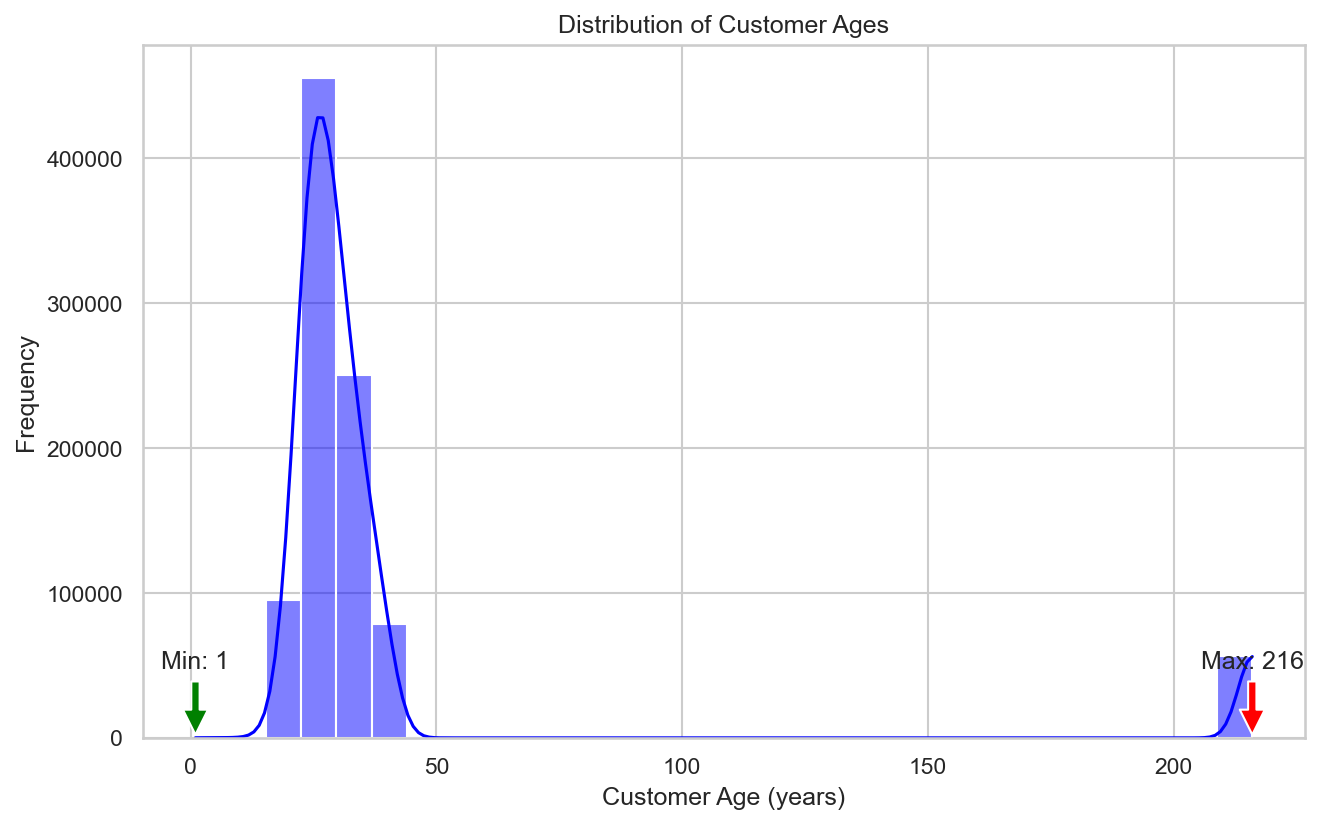

Minimum Age: 1
Maximum Age: 216


In [14]:
plt.figure(dpi=150)  #making the plot sharp and clear

#filteirng out negative and zero ages
df_positive_ages = df[df['Age'] > 0]

#plotting the histogram with KDE
sns.histplot(data = df_positive_ages, x='Age', bins=30, kde=True, color='blue')

#finding min and max ages after filtering
min_age = df_positive_ages['Age'].min()
max_age = df_positive_ages['Age'].max()

plt.title('Distribution of Customer Ages')
plt.xlabel('Customer Age (years)')
plt.ylabel('Frequency')

# Annotate min and max on x-axis
# Get the y-axis limits to place annotations visibly
y_min, y_max = plt.ylim()
annotation_y = y_max * 0.1  # Place annotations at 10% of max height

plt.annotate(f'Min: {min_age}', xy=(min_age, 0), xytext=(min_age, annotation_y),
             arrowprops=dict(facecolor='green', shrink=0.05),
             ha='center')

plt.annotate(f'Max: {max_age}', xy=(max_age, 0), xytext=(max_age, annotation_y),
             arrowprops=dict(facecolor='red', shrink=0.05),
             ha='center')

plt.show()

# Print min and max below the plot
print(f"Minimum Age: {min_age}")
print(f"Maximum Age: {max_age}")

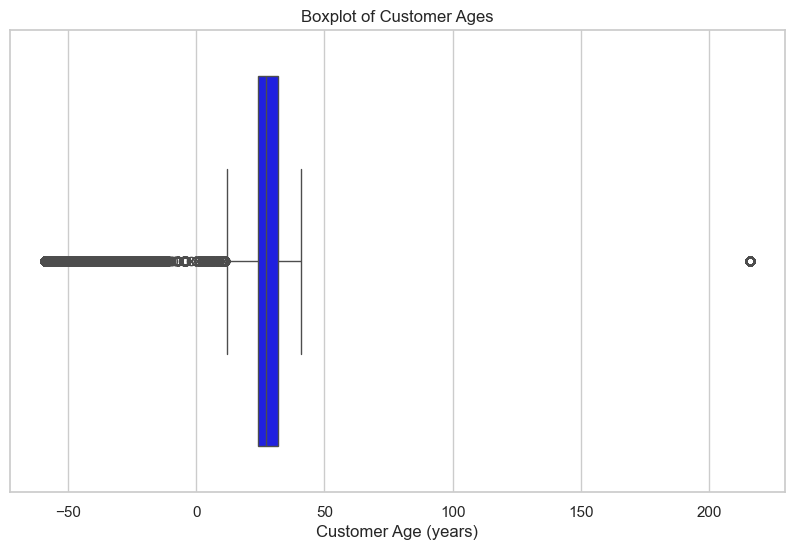

In [15]:
sns.boxplot(x=df['Age'], color= 'blue')
plt.title('Boxplot of Customer Ages')
plt.xlabel('Customer Age (years)')
plt.show()

##### &#x1F50D; The minimum and maximum ages reveal ages that are probably owned by individuals that _do not_ operate these accounts themselves or are incorrect entries. The single age above 200 is most likely an incorrect entry, along with the negative ages. However, the ages from 0 to 18 are possibly/probably accounts that were opened by parents for their children and thus operated by them, this is allowed in India (where this bank is based). Should these be dropped or kept in the dataset? Exploring further to determine this.

#### More outlier anlysis with IQR

In [16]:
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Lower bound: {lower_bound}, Upper bound: {upper_bound}")

Lower bound: 12.0, Upper bound: 44.0


In [25]:
outliers = df[(df['Age'] < lower_bound) | (df['Age'] > upper_bound)]

outliers['Age'][outliers['Age'] >= 0].value_counts() #displaying the value counts for the non-negative outliers.

Age
216    56292
9         40
10        32
4         28
11        25
1         23
8         19
2         19
3         18
6         13
5         12
7         10
0          6
Name: count, dtype: int64

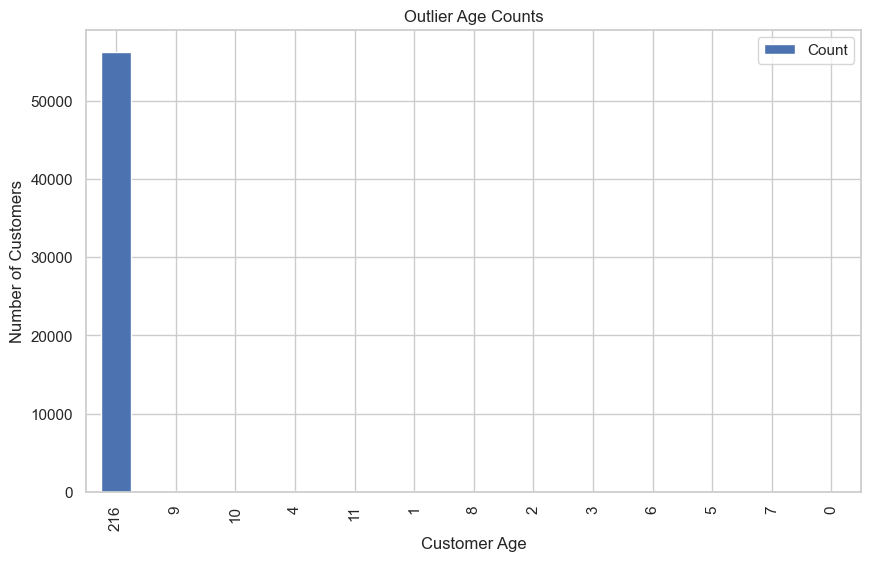

In [28]:
#visualising this.
age_outlier_table = outliers['Age'][outliers['Age'] >= 0].value_counts().reset_index()
age_outlier_table.columns = ['Age', 'Count']  #renaming columns properly

age_outlier_table.plot(kind='bar', x='Age', y='Count')
plt.title('Outlier Age Counts')
plt.xlabel('Customer Age')
plt.ylabel('Number of Customers')
plt.show()

#### &#x1F52C; Viewing the rows that have 216 as their ages. To analyse the dates of births.

In [36]:
customers_aged_216 = outliers[outliers['Age'] == 216]

customers_aged_216

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR),Age
16,T17,C1376215,1800-01-01,M,MUMBAI,77495.15,2016-08-01,124727,1423.11,216
22,T23,C7018081,1800-01-01,M,WAYS PANCHKUVA AHMEDABAD,143.07,2016-08-03,104718,110.00,216
28,T29,C7935438,1800-01-01,M,MOHALI,969436.12,2016-08-03,183634,36.90,216
34,T36,C1211387,1800-01-01,M,AHMEDABAD,11791.25,2016-08-03,125915,1075.00,216
150,T152,C3334638,1800-01-01,M,PUNE,700.00,2016-08-09,24912,1500.00,216
...,...,...,...,...,...,...,...,...,...,...
1041491,T1048444,C7261226,1800-01-01,M,BHILAI,1393.33,2016-09-18,102427,200.00,216
1041500,T1048453,C3813481,1800-01-01,M,NEW DELHI,984605.24,2016-09-18,84644,219.00,216
1041578,T1048532,C6937679,1800-01-01,M,NEW DELHI,50698.90,2016-09-18,184319,598.86,216
1041580,T1048534,C7431884,1800-01-01,M,MANDIR DHANBAD,53771.64,2016-09-18,184049,520.00,216


#### &#x2757;Confirming "1800-01-01" is the only Date of Birth for these customers, as it is incorrect and was most likely just a default value in the system.

In [37]:
customers_aged_216['CustomerDOB'].unique() #checking the unique dates of birth for these rows.

<DatetimeArray>
['1800-01-01 00:00:00']
Length: 1, dtype: datetime64[ns]

#### The "216" ages and negatives will be dropped, as they are clearly incorrect (1800-01-01 is usually default value in a lot of data entry systems). But the rest of these outliers (0 and above) may be parents who opened accounts for their children, so these will be kept. 

In [44]:
print(f"The number of rows to be dropped is {len(df[((df['Age'] == 216) | (df['Age'] < 0))])}, which is {len(df[((df['Age'] == 216) | (df['Age'] < 0))])/len(df) * 100}% of the data")

The number of rows to be dropped is 161126, which is 15.468878106477064% of the data


In [45]:
#dropping the rows where the Age is 216 or less than 0.
df_cleaned = df[~((df['Age'] == 216) | (df['Age'] < 0))]

df_cleaned

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR),Age
0,T1,C5841053,1994-01-10,F,JAMSHEDPUR,17819.05,2016-08-02,143207,25.0,22
2,T3,C4417068,1996-11-26,F,MUMBAI,17874.44,2016-08-02,142712,459.0,19
4,T5,C9031234,1988-03-24,F,NAVI MUMBAI,6714.43,2016-08-02,181156,1762.5,28
6,T7,C7126560,1992-01-26,F,MUMBAI,973.46,2016-08-02,173806,566.0,24
7,T8,C1220223,1982-01-27,M,MUMBAI,95075.54,2016-08-02,170537,148.0,34
...,...,...,...,...,...,...,...,...,...,...
1041609,T1048563,C8020229,1990-04-08,M,NEW DELHI,7635.19,2016-09-18,184824,799.0,26
1041610,T1048564,C6459278,1992-02-20,M,NASHIK,27311.42,2016-09-18,183734,460.0,24
1041611,T1048565,C6412354,1989-05-18,M,HYDERABAD,221757.06,2016-09-18,183313,770.0,27
1041612,T1048566,C6420483,1978-08-30,M,VISAKHAPATNAM,10117.87,2016-09-18,184706,1000.0,38


880488 rows remain.

In [46]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 880488 entries, 0 to 1041613
Data columns (total 10 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   TransactionID            880488 non-null  object        
 1   CustomerID               880488 non-null  object        
 2   CustomerDOB              880488 non-null  datetime64[ns]
 3   CustGender               880488 non-null  object        
 4   CustLocation             880488 non-null  object        
 5   CustAccountBalance       880488 non-null  float64       
 6   TransactionDate          880488 non-null  datetime64[ns]
 7   TransactionTime          880488 non-null  int64         
 8   TransactionAmount (INR)  880488 non-null  float64       
 9   Age                      880488 non-null  int64         
dtypes: datetime64[ns](2), float64(2), int64(2), object(4)
memory usage: 73.9+ MB
